# Monodromy methode on Schwarzschild and BCl black holes

## Schwarzschild metric

In [26]:
import numpy as np
import matplotlib.pyplot as plt

def plot_stokes_lines(x, omega, bh='Sch', xlim=10, ylim=10):
    # Create a grid of complex r values
    re = np.linspace(-xlim, xlim, 400)
    im = np.linspace(-ylim, ylim, 400)
    Re, Im = np.meshgrid(re, im)
    r = Re + 1j * Im

    # Compute Re(x(r))
    with np.errstate(divide='ignore', invalid='ignore'):
        x_r = x(r)
        x_r_real = np.imag(omega * x_r)

    # Plot contour where Re(x(r)) = 0
    plt.figure(figsize=(8, 6))
    plt.contour(Re, Im, x_r_real, levels=[0], colors='black')
    plt.title("Contour of Re(x(r)) = 0 in complex r-plane")
    plt.xlabel("Re(r)")
    plt.ylabel("Im(r)")
    plt.grid(True)
    if bh=='Sch':
        plt.plot([2*M], [0],'go', label=f'Event Horizon (r={2*M})')
    if bh=='BCL':
        plt.plot([rplus], [0], 'go', label=f'Event Horizon (r={rplus})')
        plt.plot([-rminus], [0], 'go', label=f'- r_minus (r={-rminus})')
        plt.plot([0, 0], [np.sqrt(2*rplus*rminus), -np.sqrt(2*rplus*rminus)], 'go', label=f'poles de Omega')
    plt.legend()
    cf = plt.contourf(Re, Im, x_r_real, levels=50, cmap='RdBu')
    plt.colorbar(cf, label='Re(x(r))')
    plt.show()


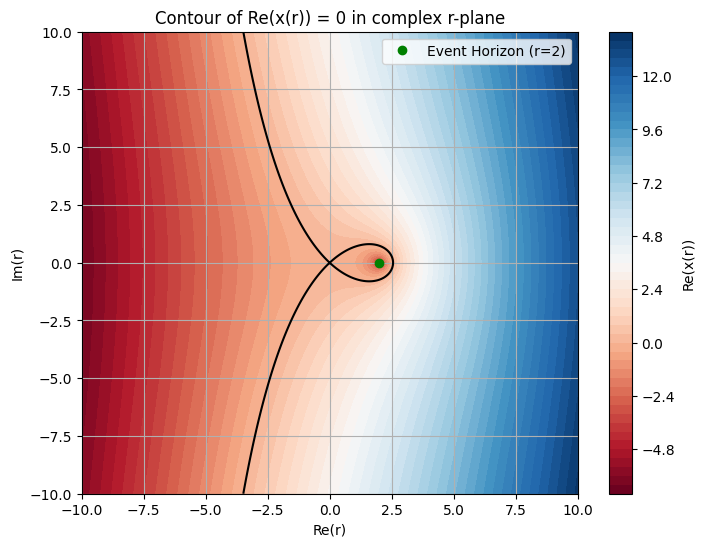

In [27]:
M = 1
theta = 1/4
def x(r):
    return r + 2*M * np.log(r / (2*M) - 1)

plot_stokes_lines(x, np.exp(np.pi*1j/2))



## Schwarzschild AdS metric

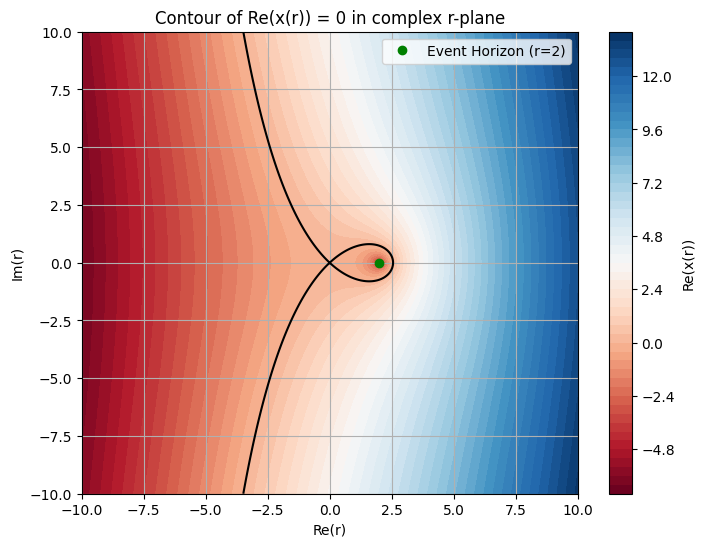

In [28]:
M = 1
lambda_ads = -1
theta = 1/4
def x(r):
    return r + 2*M * np.log(r / (2*M) - 1)

plot_stokes_lines(x, np.exp(np.pi*1j/2))

## BCL effective metric

In [ ]:
M = 1
theta = 1/4

rminus, rplus = 0.4, 2

def x(r):
    # common square roots
    sqrt_r2 = np.sqrt(r**2 + 2*rminus*rplus)
    sqrt_rminus      = np.sqrt(rminus)
    sqrt_rplus       = np.sqrt(rplus)
    sqrt_rminus_sum  = np.sqrt(rminus + 2*rplus)
    sqrt_rplus_sum   = np.sqrt(2*rminus + rplus)

    # construct the three big terms
    arg1  = (r + rminus - sqrt_r2) / (sqrt_rminus * sqrt_rminus_sum)
    term1 = 2 * rminus**(3/2) * sqrt_rminus_sum * np.arctanh(arg1)

    arg2  = (r - rplus - sqrt_r2) / (sqrt_rplus * sqrt_rplus_sum)
    term2 = 2 * rplus**(3/2)  * sqrt_rplus_sum  * np.arctanh(arg2)

    term3 = (rminus + rplus) * (sqrt_r2 + (rminus - rplus) * np.log(-r + sqrt_r2))

    # full expression
    return (term1 + term2 + term3) / (rminus + rplus)

from ipywidgets import interact
import ipywidgets as widgets

def plot_with_theta(theta):
    plot_stokes_lines(x, np.exp(theta*1j), bh="BCL", xlim=100, ylim=100)

interact(plot_with_theta, theta=widgets.FloatSlider(min=0, max=2*np.pi, step=0.01, value=0))

interactive(children=(FloatSlider(value=0.0, description='theta', max=6.283185307179586, step=0.01), Output())…

<function __main__.plot_with_theta(theta)>

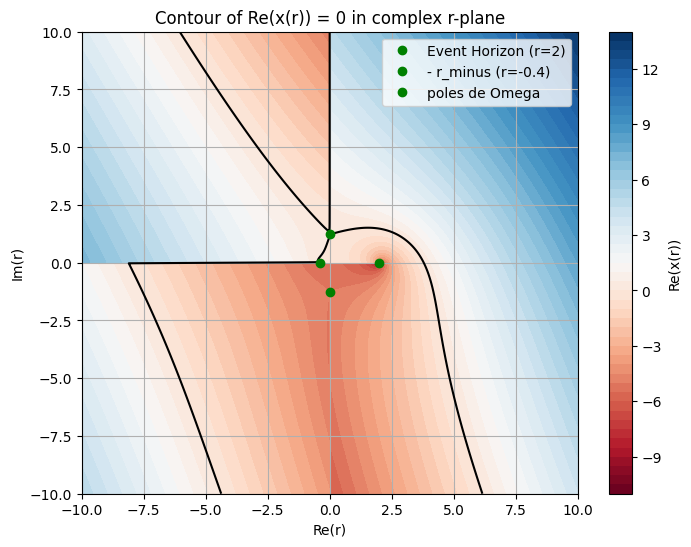

In [40]:
plot_stokes_lines(x, np.exp(1.137*1j), bh="BCL")